# 🫀 Phân loại bệnh tim — Hướng dẫn từng bước

**Mục tiêu buổi học.** Đi trọn một dự án Machine Learning thực tế: từ đọc dữ liệu thô,
tiền xử lý, huấn luyện nhiều mô hình, tinh chỉnh siêu tham số, cho đến **đánh giá
trung thực** kết quả.

**Điều đặc biệt ở notebook này.** Kết thúc buổi học, chúng ta sẽ phát hiện ra rằng
bộ dữ liệu này *không chứa tín hiệu dự đoán nào cả*. Đó không phải là thất bại —
đó là kết quả quan trọng nhất, và cách chứng minh nó là kỹ năng mà một người làm
dữ liệu chuyên nghiệp bắt buộc phải có.

| Mục | Nội dung |
|---|---|
| 1 | Nạp dữ liệu và cái bẫy `"None"` |
| 2 | Khám phá dữ liệu (EDA) |
| 3 | Tiền xử lý với `Pipeline` |
| 4 | Chia train/test và Baseline |
| 5 | Huấn luyện & so sánh 8 mô hình |
| 6 | Đường cong ROC và ma trận nhầm lẫn |
| 7 | Tinh chỉnh siêu tham số với `GridSearchCV` |
| 8 | Thí nghiệm đối chứng: xáo trộn nhãn |
| 9 | Kết luận và bài tập |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# Tìm tệp dữ liệu dù notebook chạy ở thư mục gốc hay trong notebooks/
here = Path.cwd()
DATA = next(
    p / "Dataset" / "heart_disease.csv"
    for p in (here, *here.parents)
    if (p / "Dataset" / "heart_disease.csv").exists()
)
print("Dữ liệu:", DATA)

Dữ liệu: /Users/ts00018/DataScience/heart-disease/Dataset/heart_disease.csv


---
## 1. Nạp dữ liệu — và cái bẫy đầu tiên

Hãy thử đọc file theo cách thông thường nhất và xem số giá trị thiếu.

In [2]:
df_sai = pd.read_csv(DATA)
print("Số giá trị thiếu theo cột (đọc kiểu mặc định):\n")
print((df_sai.isna().sum().sort_values(ascending=False).head(5)))

Số giá trị thiếu theo cột (đọc kiểu mặc định):

Alcohol Consumption    2586
Cholesterol Level        30
Sugar Consumption        30
Diabetes                 30
Age                      29
dtype: int64


`Alcohol Consumption` thiếu tới **2,586 ô (25.9%)** — nhiều bất thường so với các
cột khác chỉ thiếu ~25 ô.

Mở data dictionary ra đọc, ta thấy cột này có **4 mức**: `None`, `Low`, `Medium`, `High`.

Vấn đề: `pandas` mặc định coi chuỗi `"None"` là **giá trị thiếu**. Hãy kiểm chứng.

In [3]:
# Đếm trực tiếp trong file thô, không qua pandas
import csv

with open(DATA, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

tho = pd.Series([r["Alcohol Consumption"] for r in rows]).value_counts(dropna=False)
print("Giá trị thật trong file CSV:\n")
print(tho)

Giá trị thật trong file CSV:

None      2554
Medium    2500
Low       2488
High      2426
            32
Name: count, dtype: int64


Đúng như dự đoán: **2,554 dòng có giá trị `"None"`** hoàn toàn hợp lệ — nghĩa là
*người không uống rượu*, một nhóm rất quan trọng về mặt y học. Chỉ 32 ô là thiếu thật.

Cách đọc đúng: tắt danh sách NA mặc định của pandas.

In [4]:
df = pd.read_csv(DATA, keep_default_na=False, na_values=[""])

print("Alcohol Consumption sau khi đọc đúng:")
print(df["Alcohol Consumption"].value_counts(dropna=False), "\n")
print(f"Thiếu thật: {df['Alcohol Consumption'].isna().sum()} ô "
      f"({df['Alcohol Consumption'].isna().mean():.2%})")

Alcohol Consumption sau khi đọc đúng:
Alcohol Consumption
None      2554
Medium    2500
Low       2488
High      2426
NaN         32
Name: count, dtype: int64 

Thiếu thật: 32 ô (0.32%)


> ### 📌 Bài học 1
> **Luôn đối chiếu dữ liệu với data dictionary trước khi làm bất cứ điều gì khác.**
> Nếu bỏ qua bước này, ta đã vứt đi 25% một cột hợp lệ — hoặc tệ hơn, điền trung vị
> đè lên 2,554 giá trị đúng.

---
## 2. Khám phá dữ liệu (EDA)

In [5]:
TARGET = "Heart Disease Status"

print(f"Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Dòng trùng lặp: {df.duplicated().sum()}")
print(f"Dòng có ít nhất 1 ô thiếu: {df.isna().any(axis=1).sum():,} "
      f"({df.isna().any(axis=1).mean():.1%})")
df.head()

Kích thước: 10,000 dòng × 21 cột
Dòng trùng lặp: 0
Dòng có ít nhất 1 ô thiếu: 500 (5.0%)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


### 2.1 Biến mục tiêu mất cân bằng nghiêm trọng

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64 

Tỷ lệ mắc bệnh: 20.0%


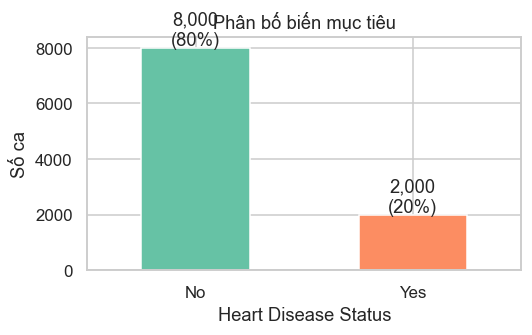

In [6]:
phan_bo = df[TARGET].value_counts()
print(phan_bo, "\n")
print(f"Tỷ lệ mắc bệnh: {(df[TARGET] == 'Yes').mean():.1%}")

fig, ax = plt.subplots(figsize=(5, 3.2))
phan_bo.plot.bar(ax=ax, color=["#66c2a5", "#fc8d62"], rot=0)
ax.set_title("Phân bố biến mục tiêu")
ax.set_ylabel("Số ca")
for i, v in enumerate(phan_bo):
    ax.text(i, v + 100, f"{v:,}\n({v/len(df):.0%})", ha="center")
plt.tight_layout()
plt.show()

⚠️ **Chỉ 20% là ca bệnh.** Hệ quả cực kỳ quan trọng: một mô hình ngớ ngẩn luôn đoán
*"không bệnh"* sẽ đạt ngay **80% accuracy** mà không học gì cả.

Ghi nhớ con số **80%** này — nó sẽ quay lại ám ảnh chúng ta.

### 2.2 Giá trị thiếu

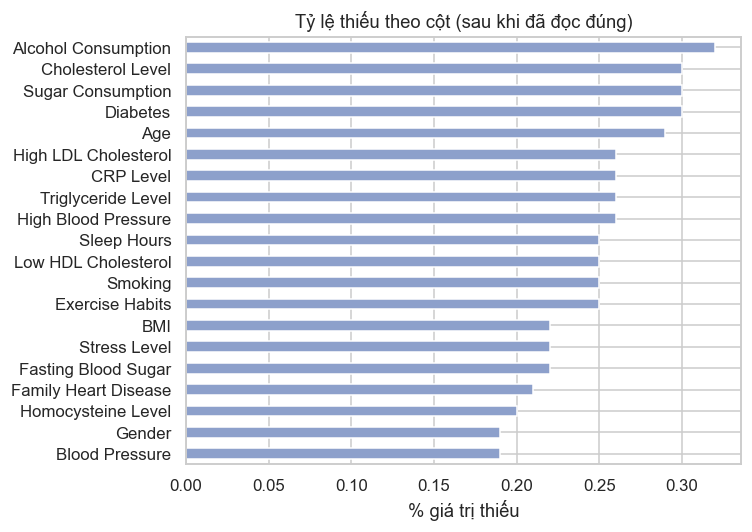

Cột thiếu nhiều nhất: 0.32%


In [7]:
thieu = (df.isna().mean() * 100).sort_values(ascending=False)
thieu = thieu[thieu > 0]

fig, ax = plt.subplots(figsize=(7, 5))
thieu.plot.barh(ax=ax, color="#8da0cb")
ax.set_xlabel("% giá trị thiếu")
ax.set_title("Tỷ lệ thiếu theo cột (sau khi đã đọc đúng)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Cột thiếu nhiều nhất: {thieu.iloc[0]:.2f}%")

Mọi cột chỉ thiếu ~0.2–0.3% và khá đồng đều — dấu hiệu dữ liệu bị khoét lỗ ngẫu nhiên.
Tổng cộng chỉ 500 ô trống trên 200,000 ô, ảnh hưởng **500 dòng (5.0%)**.

Hãy đối chiếu với cách đọc sai ở mục 1: khi `"None"` bị nuốt thành `NaN`, con số này
phồng lên **2,933 dòng (29.3%)** — gấp gần 6 lần. Một lỗi đọc dữ liệu làm sai lệch
toàn bộ đánh giá về chất lượng dữ liệu.

> ### 📌 Bài học 2
> Đừng `dropna()` theo phản xạ, và đừng đánh giá mức độ thiếu dữ liệu trước khi chắc
> chắn đã đọc đúng. Với những ô thiếu lẻ tẻ, hãy **điền khuyết (impute)** thay vì
> xoá dòng.

### 2.3 Các biến có liên hệ gì với bệnh không?

Đây là câu hỏi quan trọng nhất của EDA. Hãy xem tỷ lệ mắc bệnh trong từng nhóm.

In [8]:
cat_cols = [c for c in df.columns
            if df[c].dtype == object and c != TARGET]

print(f"Mức nền (tỷ lệ mắc bệnh chung): {(df[TARGET]=='Yes').mean():.1%}\n")
print(f"{'Biến':24s} {'Nhóm':10s} {'Tỷ lệ mắc bệnh':>16s}")
print("-" * 54)
for col in cat_cols[:6]:
    ty_le = df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean())
    for nhom, v in ty_le.items():
        print(f"{col:24s} {str(nhom):10s} {v:15.1%}")
    print()

Mức nền (tỷ lệ mắc bệnh chung): 20.0%

Biến                     Nhóm         Tỷ lệ mắc bệnh
------------------------------------------------------
Gender                   Female               20.7%
Gender                   Male                 19.4%

Exercise Habits          High                 20.0%
Exercise Habits          Low                  19.7%
Exercise Habits          Medium               20.4%

Smoking                  No                   19.9%
Smoking                  Yes                  20.1%

Family Heart Disease     No                   20.2%
Family Heart Disease     Yes                  19.7%

Diabetes                 No                   20.1%
Diabetes                 Yes                  19.9%

High Blood Pressure      No                   19.9%
High Blood Pressure      Yes                  20.1%



👀 **Hãy nhìn kỹ bảng trên.** Người hút thuốc mắc bệnh 20.1%, người không hút 19.9%.
Có tiền sử gia đình: 19.7%, không có: 20.2% — *ngược chiều* với y học!

Mọi nhóm đều dao động quanh đúng mức nền 20%. Đây là tín hiệu cảnh báo rất sớm.

Thử với các biến liên tục bằng hệ số tương quan.

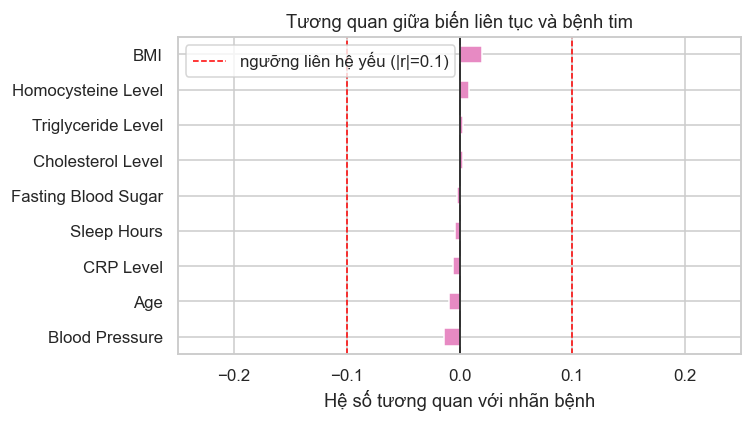

Blood Pressure        -0.0139
Age                   -0.0092
CRP Level             -0.0060
Sleep Hours           -0.0038
Fasting Blood Sugar   -0.0022
Cholesterol Level      0.0027
Triglyceride Level     0.0029
Homocysteine Level     0.0083
BMI                    0.0197
dtype: float64


In [9]:
num_cols = df.select_dtypes("number").columns.tolist()
y = (df[TARGET] == "Yes").astype(int)
tuong_quan = df[num_cols].corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
tuong_quan.plot.barh(ax=ax, color="#e78ac3")
ax.axvline(0, color="black", lw=1)
ax.axvline(0.1, color="red", ls="--", lw=1)
ax.axvline(-0.1, color="red", ls="--", lw=1, label="ngưỡng liên hệ yếu (|r|=0.1)")
ax.set_xlim(-0.25, 0.25)
ax.set_xlabel("Hệ số tương quan với nhãn bệnh")
ax.set_title("Tương quan giữa biến liên tục và bệnh tim")
ax.legend()
plt.tight_layout()
plt.show()

print(tuong_quan.round(4))

Mọi hệ số đều nằm trong khoảng **±0.02**, trong khi ngay cả một liên hệ *yếu* trong
y học thực tế cũng thường đạt |r| > 0.1 (vạch đỏ).

Ta tạm ghi nhận nghi ngờ này và cứ tiếp tục quy trình — vì đôi khi mô hình phi tuyến
có thể bắt được quan hệ mà tương quan tuyến tính bỏ sót.

---
## 3. Tiền xử lý với `Pipeline`

Mô hình chỉ ăn được **số**. Ta phải biến 20 cột thô thành ma trận số, và mỗi *loại*
biến cần một cách xử lý riêng.

In [10]:
NUMERIC_COLS = [
    "Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours",
    "Triglyceride Level", "Fasting Blood Sugar", "CRP Level", "Homocysteine Level",
]

# Biến THỨ BẬC: thứ tự có ý nghĩa -> mã hoá thành số tăng dần
ORDINAL_COLS = {
    "Exercise Habits":     ["Low", "Medium", "High"],
    "Alcohol Consumption": ["None", "Low", "Medium", "High"],
    "Stress Level":        ["Low", "Medium", "High"],
    "Sugar Consumption":   ["Low", "Medium", "High"],
}

# Biến DANH MỤC: không có thứ tự -> one-hot
NOMINAL_COLS = [
    "Gender", "Smoking", "Family Heart Disease", "Diabetes",
    "High Blood Pressure", "Low HDL Cholesterol", "High LDL Cholesterol",
]

FEATURE_COLS = NUMERIC_COLS + list(ORDINAL_COLS) + NOMINAL_COLS
print(f"{len(NUMERIC_COLS)} biến liên tục + {len(ORDINAL_COLS)} thứ bậc "
      f"+ {len(NOMINAL_COLS)} danh mục = {len(FEATURE_COLS)} biến đầu vào")

9 biến liên tục + 4 thứ bậc + 7 danh mục = 20 biến đầu vào


**Vì sao phải phân biệt thứ bậc và danh mục?**

- `Low < Medium < High` có thứ tự thật → mã hoá `0 < 1 < 2` giữ được thông tin đó.
- `Male` / `Female` không có thứ tự → nếu gán 0/1, mô hình tuyến tính sẽ hiểu nhầm là
  *"Female lớn hơn Male"*. Phải dùng **one-hot**.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


def build_preprocessor(scale=True):
    """Điền khuyết -> mã hoá -> chuẩn hoá. scale=False cho mô hình cây."""
    buoc_so = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        buoc_so.append(("scale", StandardScaler()))

    return ColumnTransformer([
        ("num", Pipeline(buoc_so), NUMERIC_COLS),
        ("ord", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OrdinalEncoder(categories=list(ORDINAL_COLS.values()))),
        ]), list(ORDINAL_COLS)),
        ("nom", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
        ]), NOMINAL_COLS),
    ])


prep = build_preprocessor()
print(prep)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Age', 'Blood Pressure', 'Cholesterol Level',
                                  'BMI', 'Sleep Hours', 'Triglyceride Level',
                                  'Fasting Blood Sugar', 'CRP Level',
                                  'Homocysteine Level']),
                                ('ord',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  Ordi...
                                                                              'Medium',
                                                   

> ### 📌 Bài học 3 — Rò rỉ dữ liệu (Data Leakage)
>
> Trung vị dùng để điền khuyết **phải tính chỉ trên tập train**.
>
> Nếu bạn làm `df.fillna(df.median())` trên toàn bộ dữ liệu *trước khi* chia train/test,
> thông tin từ tập test đã rò rỉ sang tập train. Điểm số sẽ đẹp giả tạo và mô hình
> sẽ sụp đổ khi gặp dữ liệu thật.
>
> **Giải pháp: bọc mọi bước vào `Pipeline`.** `sklearn` sẽ tự động chỉ `fit` trên
> phần train của mỗi fold.

---
## 4. Chia train/test và dựng Baseline

In [12]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = (df[TARGET] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y,   # giữ nguyên tỷ lệ 80/20 ở cả hai tập
)

print(f"Train: {X_train.shape[0]:,} dòng, tỷ lệ bệnh {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]:,} dòng, tỷ lệ bệnh {y_test.mean():.1%}")

# Xem thử ma trận sau tiền xử lý
A = prep.fit_transform(X_train)
print(f"\nSau tiền xử lý: {X_train.shape} -> {A.shape}")
print("Không còn ô thiếu:", not np.isnan(A).any())

Train: 8,000 dòng, tỷ lệ bệnh 20.0%
Test:  2,000 dòng, tỷ lệ bệnh 20.0%

Sau tiền xử lý: (8000, 20) -> (8000, 20)
Không còn ô thiếu: True


`stratify=y` là bắt buộc với dữ liệu lệch lớp — nếu không, tập test có thể vô tình
chứa quá ít ca bệnh và mọi chỉ số trở nên vô nghĩa.

### Baseline — mốc so sánh bắt buộc

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
bl_acc = accuracy_score(y_test, baseline.predict(X_test))
bl_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])

print(f"Baseline (luôn đoán 'không bệnh'):")
print(f"  Accuracy = {bl_acc:.1%}   <-- hãy nhớ con số này")
print(f"  ROC-AUC  = {bl_auc:.3f}")

Baseline (luôn đoán 'không bệnh'):
  Accuracy = 80.0%   <-- hãy nhớ con số này
  ROC-AUC  = 0.500


> ### 📌 Bài học 4
> **Không có Baseline thì không thể biết mô hình của bạn giỏi hay dở.**
> Mọi mô hình phải được so với mốc này. 80% accuracy nghe rất ấn tượng — cho đến khi
> bạn biết rằng đoán bừa cũng được đúng 80%.

---
## 5. Huấn luyện và so sánh 8 mô hình

In [14]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# (tên, mô hình, có cần chuẩn hoá thang đo không)
MODELS = [
    ("Baseline (đoán lớp đa số)", DummyClassifier(strategy="most_frequent"), False),
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    ("Logistic Regression (cân bằng)",
     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE), True),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=25), True),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), False),
    ("Random Forest",
     RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1), False),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
    ("LightGBM",
     LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), False),
]
print(f"Sẽ huấn luyện {len(MODELS)} mô hình.")

Sẽ huấn luyện 8 mô hình.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ket_qua, duong_cong, da_fit = [], {}, {}

for ten, clf, scale in MODELS:
    pipe = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    ket_qua.append({
        "Mô hình": ten,
        "CV ROC-AUC": cv_auc.mean(),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
    })
    duong_cong[ten] = roc_curve(y_test, y_proba)[:2]
    da_fit[ten] = pipe
    print(f"  ✓ {ten}")

bang = pd.DataFrame(ket_qua).sort_values("ROC-AUC", ascending=False)
bang.round(4)

  ✓ Baseline (đoán lớp đa số)


  ✓ Logistic Regression


  ✓ Logistic Regression (cân bằng)


  ✓ K-Nearest Neighbors


  ✓ Decision Tree


  ✓ Random Forest


  ✓ HistGradientBoosting


  ✓ LightGBM


,Mô hình,CV ROC-AUC,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline (đoán lớp đa số),0.5000,0.8000,0.5000,0.0000,0.0000,0.0000,0.5000,0.2000
4,Decision Tree,0.5031,0.7975,0.5012,0.2727,0.0075,0.0146,0.4981,0.2027
7,LightGBM,0.4890,0.7970,0.4981,0.0000,0.0000,0.0000,0.4945,0.1950
5,Random Forest,0.4957,0.8000,0.5000,0.0000,0.0000,0.0000,0.4913,0.1933
3,K-Nearest Neighbors,0.5000,0.8000,0.5000,0.0000,0.0000,0.0000,0.4911,0.1971
6,HistGradientBoosting,0.4932,0.7970,0.4981,0.0000,0.0000,0.0000,0.4849,0.1957
2,Logistic Regression (cân bằng),0.5148,0.5040,0.4725,0.1810,0.4200,0.2530,0.4689,0.1858
1,Logistic Regression,0.5145,0.8000,0.5000,0.0000,0.0000,0.0000,0.4680,0.1852


### 🔍 Hãy đọc bảng này thật kỹ

Ba điều cần nhận ra ngay:

1. **Cột `Accuracy`:** nhiều mô hình đạt đúng **0.800** — *bằng y hệt Baseline đoán bừa*.
2. **Cột `ROC-AUC`:** tất cả đều quanh **0.50**, tức ngang với tung đồng xu.
3. **Cột `Recall`:** phần lớn bằng **0.000** — mô hình không bắt được *một ca bệnh nào*.

Mô hình đã học được cách "ăn gian": cứ đoán *không bệnh* cho tất cả mọi người là đạt
80% accuracy.

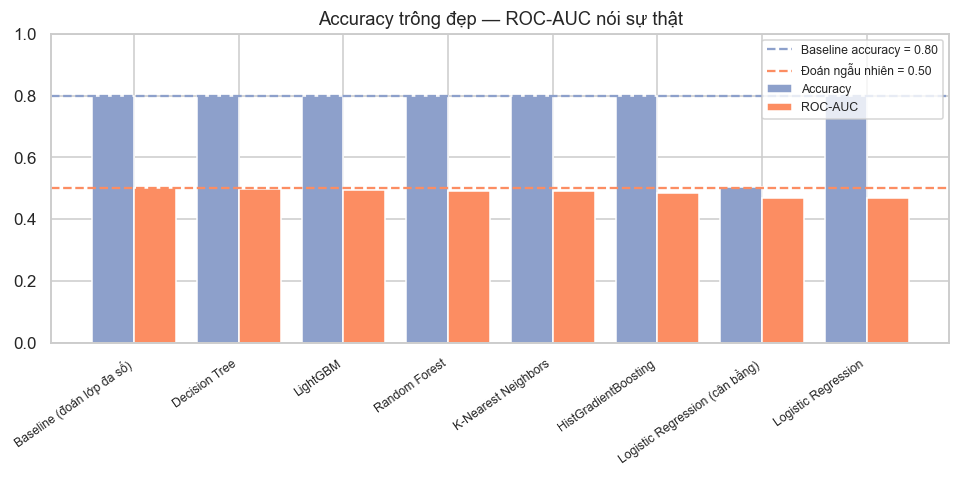

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(bang))
ax.bar(x - 0.2, bang["Accuracy"], 0.4, label="Accuracy", color="#8da0cb")
ax.bar(x + 0.2, bang["ROC-AUC"], 0.4, label="ROC-AUC", color="#fc8d62")
ax.axhline(0.8, color="#8da0cb", ls="--", lw=1.5, label="Baseline accuracy = 0.80")
ax.axhline(0.5, color="#fc8d62", ls="--", lw=1.5, label="Đoán ngẫu nhiên = 0.50")
ax.set_xticks(x)
ax.set_xticklabels(bang["Mô hình"], rotation=35, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Accuracy trông đẹp — ROC-AUC nói sự thật")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> ### 📌 Bài học 5 — Cái bẫy Accuracy
> Với dữ liệu mất cân bằng, **accuracy là chỉ số gây hiểu lầm nhất**.
> Luôn báo cáo kèm **ROC-AUC, Precision, Recall, F1** hoặc **Balanced Accuracy**.

---
## 6. Đường cong ROC và ma trận nhầm lẫn

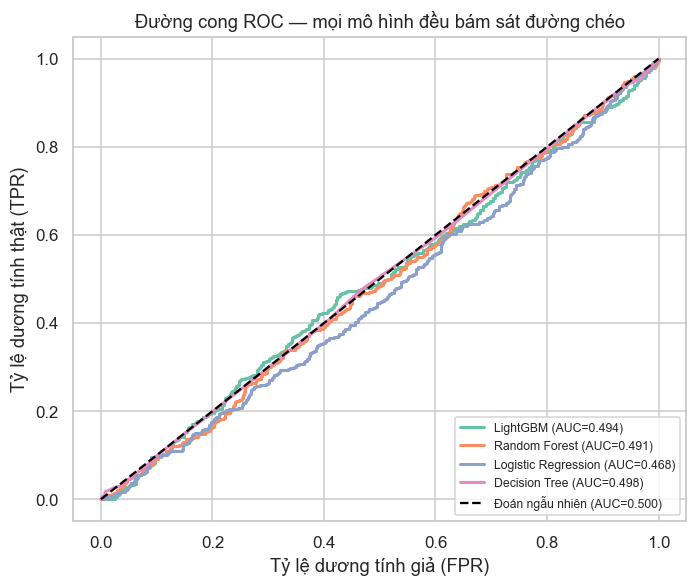

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for ten in ["LightGBM", "Random Forest", "Logistic Regression", "Decision Tree"]:
    fpr, tpr = duong_cong[ten]
    auc = bang.loc[bang["Mô hình"] == ten, "ROC-AUC"].iloc[0]
    ax.plot(fpr, tpr, lw=2, label=f"{ten} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Đoán ngẫu nhiên (AUC=0.500)")
ax.set_xlabel("Tỷ lệ dương tính giả (FPR)")
ax.set_ylabel("Tỷ lệ dương tính thật (TPR)")
ax.set_title("Đường cong ROC — mọi mô hình đều bám sát đường chéo")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Đường ROC càng vồng lên góc **trái trên** thì mô hình càng tốt. Ở đây mọi đường đều
bám sát đường chéo đứt nét — mô hình không phân biệt được ca bệnh và ca lành.

### Ma trận nhầm lẫn — nhìn vào hậu quả thực tế

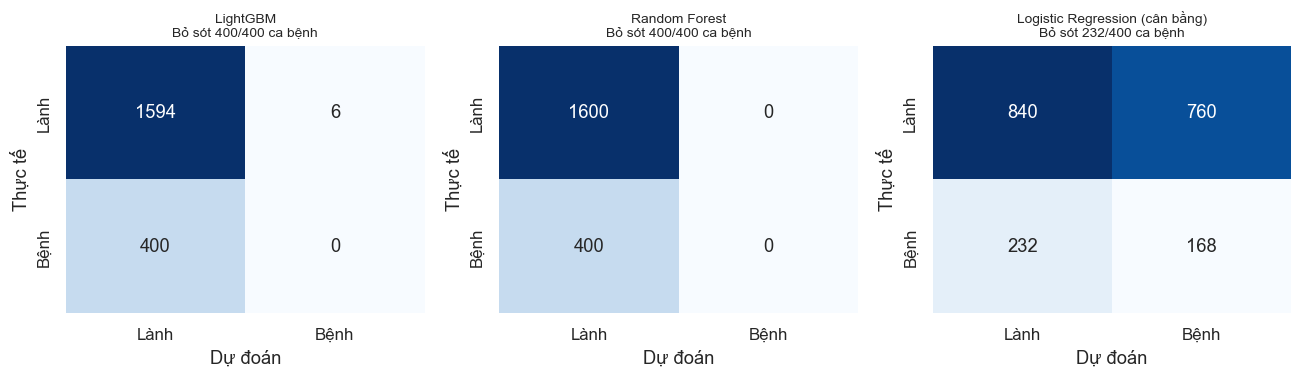

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, ten in zip(axes, ["LightGBM", "Random Forest", "Logistic Regression (cân bằng)"]):
    cm = confusion_matrix(y_test, da_fit[ten].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Lành", "Bệnh"], yticklabels=["Lành", "Bệnh"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{ten}\nBỏ sót {fn}/{fn+tp} ca bệnh", fontsize=9)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
plt.show()

**Hai loại sai lầm không hề ngang nhau trong y tế:**

- **FN (bỏ sót ca bệnh)** — bệnh nhân bị bỏ về, có thể tử vong. Rất nghiêm trọng.
- **FP (báo động nhầm)** — bệnh nhân lo lắng, tốn tiền xét nghiệm thêm. Khó chịu nhưng an toàn.

Mô hình `class_weight="balanced"` chấp nhận hy sinh accuracy để bắt được nhiều ca bệnh
hơn (recall cao hơn). Đó là đánh đổi đúng đắn trong bài toán sàng lọc — **nếu** mô hình
thực sự có năng lực dự đoán.

---
## 7. Tinh chỉnh siêu tham số với `GridSearchCV`

**Siêu tham số** là các lựa chọn ta đặt *trước* khi huấn luyện (độ sâu cây, số cây,
tốc độ học…). Mô hình không tự học chúng.

`GridSearchCV` thử **mọi tổ hợp** trong lưới, chấm điểm bằng cross-validation,
rồi giữ tổ hợp tốt nhất.

In [19]:
from sklearn.model_selection import GridSearchCV

# Tiền tố "clf__" trỏ tham số vào bước tên "clf" bên trong Pipeline
grid = {
    "clf__n_estimators":     [100, 300],
    "clf__max_depth":        [4, 8, None],
    "clf__min_samples_leaf": [1, 20],
}

pipe_rf = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

so_to_hop = 2 * 3 * 2
print(f"{so_to_hop} tổ hợp × 5 fold = {so_to_hop * 5} lần huấn luyện. Đang chạy...")

search = GridSearchCV(
    pipe_rf, grid,
    scoring="roc_auc",        # KHÔNG dùng accuracy khi dữ liệu lệch lớp!
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
search.fit(X_train, y_train)

print(f"\nTổ hợp tốt nhất: {search.best_params_}")
print(f"Điểm CV tốt nhất: {search.best_score_:.4f}")

12 tổ hợp × 5 fold = 60 lần huấn luyện. Đang chạy...



Tổ hợp tốt nhất: {'clf__max_depth': None, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
Điểm CV tốt nhất: 0.5060


### So sánh: mặc định vs đã tinh chỉnh, trên **tập test**

In [20]:
mac_dinh = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

auc_mac_dinh = roc_auc_score(y_test, mac_dinh.predict_proba(X_test)[:, 1])
auc_tinh_chinh = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:, 1])
do_lech_cv = search.cv_results_["std_test_score"][search.best_index_]

print(f"Test ROC-AUC (mặc định):      {auc_mac_dinh:.4f}")
print(f"Test ROC-AUC (đã tinh chỉnh): {auc_tinh_chinh:.4f}")
print(f"Cải thiện:                    {auc_tinh_chinh - auc_mac_dinh:+.4f}")
print(f"\nĐộ lệch chuẩn giữa các fold:  ±{do_lech_cv:.4f}  <-- biên độ nhiễu tự nhiên")

Test ROC-AUC (mặc định):      0.5127
Test ROC-AUC (đã tinh chỉnh): 0.4851
Cải thiện:                    -0.0275

Độ lệch chuẩn giữa các fold:  ±0.0257  <-- biên độ nhiễu tự nhiên


### 🚨 Nghịch lý quan trọng

Điểm **cross-validation tăng** lên sau khi tinh chỉnh, nhưng điểm trên **tập test lại
không tăng — thậm chí giảm**.

Đây là **overfitting lên tập validation**. Khi bạn thử hàng chục tổ hợp rồi chọn tổ hợp
có điểm CV cao nhất, bạn đang chọn tổ hợp *may mắn nhất* với cách chia fold cụ thể đó,
chứ không phải tổ hợp *tốt nhất* thật sự. Càng thử nhiều tổ hợp, rủi ro càng lớn.

Hãy so sánh mức "cải thiện" với **biên độ nhiễu ±std** ở trên: hai con số cùng cỡ với nhau. Khi mức thay đổi không lớn hơn hẳn độ dao động tự nhiên giữa các fold, ta **không có cơ sở** để nói tinh chỉnh đã giúp ích.

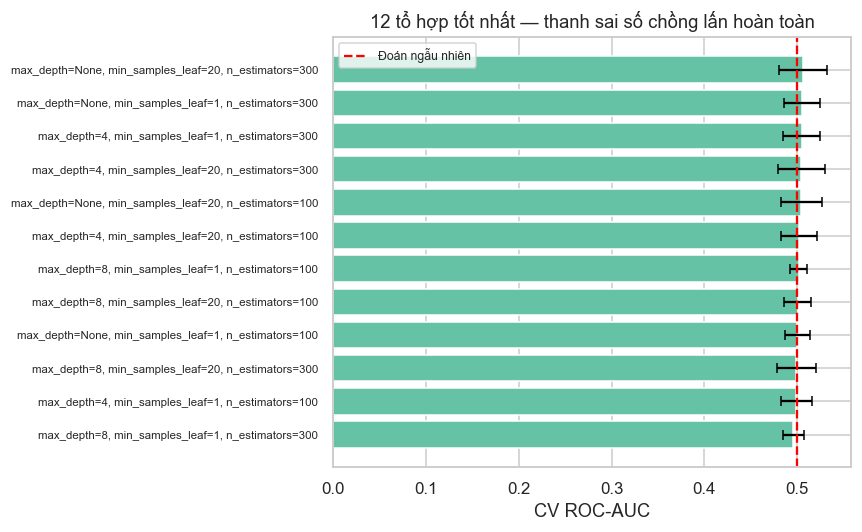

Chênh lệch train-validation lớn nhất: 0.500 (dấu hiệu học vẹt)


In [21]:
kq = pd.DataFrame(search.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")

fig, ax = plt.subplots(figsize=(8, 5))
top = kq.head(12).iloc[::-1]
nhan = [", ".join(f"{k.replace('clf__','')}={v}" for k, v in p.items()) for p in top["params"]]
ax.barh(range(len(top)), top["mean_test_score"], xerr=top["std_test_score"],
        color="#66c2a5", capsize=3)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(nhan, fontsize=7.5)
ax.axvline(0.5, color="red", ls="--", label="Đoán ngẫu nhiên")
ax.set_xlabel("CV ROC-AUC")
ax.set_title("12 tổ hợp tốt nhất — thanh sai số chồng lấn hoàn toàn")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

chenh = (kq["mean_train_score"] - kq["mean_test_score"]).max()
print(f"Chênh lệch train-validation lớn nhất: {chenh:.3f} (dấu hiệu học vẹt)")

> ### 📌 Bài học 6
> - **Điểm CV tốt nhất không bao giờ được dùng để báo cáo.** Luôn giữ riêng một tập
>   test chưa từng đụng tới cho lần đánh giá cuối cùng.
> - **`GridSearchCV` phải chạy qua `Pipeline`**, nếu không mỗi fold sẽ bị rò rỉ dữ liệu.
> - **Tinh chỉnh chỉ khai thác tốt hơn tín hiệu đã có sẵn.** Nó không tạo ra tín hiệu
>   từ hư không.

---
## 8. Thí nghiệm đối chứng — bằng chứng quyết định

Đến đây ta đã rất nghi ngờ. Làm sao **chứng minh dứt khoát** rằng dữ liệu không có
tín hiệu, chứ không phải do ta code sai?

**Ý tưởng:** xáo trộn ngẫu nhiên toàn bộ nhãn của tập train, phá huỷ mọi liên hệ giữa
triệu chứng và bệnh, rồi huấn luyện lại.

- Nếu dữ liệu **có** tín hiệu → điểm số phải **sụt mạnh**.
- Nếu dữ liệu **không** có tín hiệu → điểm số **không đổi**.

In [22]:
rng = np.random.default_rng(RANDOM_STATE)
y_xao_tron = pd.Series(rng.permutation(y_train.values), index=y_train.index)

print(f"Nhãn thật  - tỷ lệ bệnh: {y_train.mean():.1%}")
print(f"Nhãn xáo trộn - tỷ lệ bệnh: {y_xao_tron.mean():.1%}  (giữ nguyên, chỉ đảo thứ tự)")
print(f"Số nhãn bị đổi chỗ: {(y_train.values != y_xao_tron.values).sum():,} / {len(y_train):,}")

Nhãn thật  - tỷ lệ bệnh: 20.0%
Nhãn xáo trộn - tỷ lệ bệnh: 20.0%  (giữ nguyên, chỉ đảo thứ tự)
Số nhãn bị đổi chỗ: 2,578 / 8,000


In [23]:
so_sanh = []
for ten in ["Decision Tree", "Random Forest", "LightGBM", "Logistic Regression"]:
    clf, scale = next((c, s) for t, c, s in MODELS if t == ten)

    that = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])
    that.fit(X_train, y_train)
    auc_that = roc_auc_score(y_test, that.predict_proba(X_test)[:, 1])

    xao = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])
    xao.fit(X_train, y_xao_tron)
    auc_xao = roc_auc_score(y_test, xao.predict_proba(X_test)[:, 1])

    so_sanh.append({
        "Mô hình": ten,
        "ROC-AUC (nhãn THẬT)": auc_that,
        "ROC-AUC (nhãn XÁO TRỘN)": auc_xao,
        "Chênh lệch": auc_that - auc_xao,
    })

bang_dc = pd.DataFrame(so_sanh)
bang_dc.round(4)

,Mô hình,ROC-AUC (nhãn THẬT),ROC-AUC (nhãn XÁO TRỘN),Chênh lệch
0,Decision Tree,0.4981,0.5176,-0.0195
1,Random Forest,0.4913,0.5038,-0.0125
2,LightGBM,0.4945,0.5265,-0.0320
3,Logistic Regression,0.4680,0.4945,-0.0266


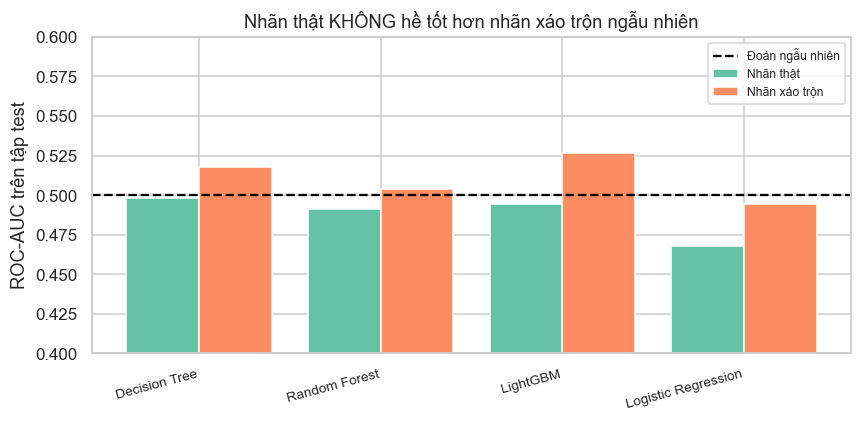

Chênh lệch trung bình: -0.0226
(nếu dữ liệu có tín hiệu thật, con số này phải LỚN và DƯƠNG rõ rệt)


In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(bang_dc))
ax.bar(x - 0.2, bang_dc["ROC-AUC (nhãn THẬT)"], 0.4, label="Nhãn thật", color="#66c2a5")
ax.bar(x + 0.2, bang_dc["ROC-AUC (nhãn XÁO TRỘN)"], 0.4, label="Nhãn xáo trộn", color="#fc8d62")
ax.axhline(0.5, color="black", ls="--", lw=1.5, label="Đoán ngẫu nhiên")
ax.set_xticks(x)
ax.set_xticklabels(bang_dc["Mô hình"], rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.4, 0.6)
ax.set_ylabel("ROC-AUC trên tập test")
ax.set_title("Nhãn thật KHÔNG hề tốt hơn nhãn xáo trộn ngẫu nhiên")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Chênh lệch trung bình: {bang_dc['Chênh lệch'].mean():+.4f}")
print("(nếu dữ liệu có tín hiệu thật, con số này phải LỚN và DƯƠNG rõ rệt)")

### ✅ Kết luận dứt khoát

**Huấn luyện trên nhãn ngẫu nhiên cho kết quả ngang bằng — có khi còn nhỉnh hơn —
nhãn thật.**

Mô hình hoàn toàn không học được quan hệ nào giữa đặc trưng và bệnh. Mọi chênh lệch
nhỏ chỉ là nhiễu ngẫu nhiên.

Bộ dữ liệu này là **dữ liệu nhân tạo sinh ngẫu nhiên** — các biến đầu vào độc lập
thống kê với nhãn.

> ### 📌 Bài học 7 — Thí nghiệm đối chứng
> Hãy biến đây thành **thói quen bắt buộc** trong mọi dự án ML. Nó phát hiện được
> cả hai lỗi chí mạng:
> - **Dữ liệu vô dụng** (như trường hợp này): nhãn xáo trộn cũng tốt ngang nhãn thật.
> - **Rò rỉ dữ liệu**: điểm số cao bất thường ở *cả hai* trường hợp.

---
## 9. Kết luận

### Tóm tắt 7 bài học

| # | Bài học |
|---|---|
| 1 | Luôn đối chiếu dữ liệu với data dictionary — chuỗi `"None"` suýt làm mất 25% một cột |
| 2 | Đừng `dropna()` theo phản xạ; đọc sai làm mức thiếu phồng từ 5.0% lên 29.3% |
| 3 | Bọc mọi bước vào `Pipeline` để chống rò rỉ dữ liệu |
| 4 | Luôn dựng Baseline — không có mốc thì không biết mô hình giỏi hay dở |
| 5 | Accuracy nói dối khi dữ liệu lệch lớp — 80% ở đây = không làm gì cả |
| 6 | Điểm CV tốt nhất không dùng để báo cáo — nó đã bị overfit lên validation |
| 7 | Luôn chạy thí nghiệm đối chứng bằng nhãn xáo trộn |

### Thông điệp quan trọng nhất

> Một kết quả **ROC-AUC = 0.5 được chứng minh cẩn thận** là một kết quả **đúng và có
> giá trị khoa học**.
>
> Biết dừng lại và nói *"dữ liệu này không trả lời được câu hỏi đặt ra"* là **kỹ năng
> chuyên nghiệp**, không phải thất bại.
>
> Sai lầm thực sự là cố ép mô hình cho ra một con số đẹp rồi đem đi báo cáo — trong y tế,
> điều đó có thể khiến người bệnh bị bỏ sót.

Mô hình mạnh không cứu được dữ liệu yếu. LightGBM, Random Forest, Boosting đều thua,
vì **không thuật toán nào tạo ra được thông tin mà dữ liệu không có**.

---
## 🎓 Bài tập về nhà

**Bài 1 — Ngưỡng quyết định.**
Mặc định mô hình phân loại "có bệnh" khi xác suất > 0.5. Hãy thử hạ ngưỡng xuống 0.3
và 0.2. Precision, Recall, F1 thay đổi ra sao? Trong bài toán sàng lọc y tế, bạn chọn
ngưỡng nào và vì sao?

```python
y_proba = da_fit["LightGBM"].predict_proba(X_test)[:, 1]
for nguong in [0.5, 0.3, 0.2, 0.15]:
    y_pred = (y_proba > nguong).astype(int)
    # tính precision, recall, f1 ở đây
```

**Bài 2 — Mô phỏng dữ liệu CÓ tín hiệu.**
Dùng `sklearn.datasets.make_classification` tạo bộ dữ liệu 10,000 dòng, 20 biến,
`weights=[0.8, 0.2]`, nhưng có `n_informative=6`. Chạy lại toàn bộ quy trình.
ROC-AUC đạt bao nhiêu? Đường ROC trông khác thế nào?

**Bài 3 — Tự tạo rò rỉ dữ liệu.**
Cố tình làm sai: điền khuyết và chuẩn hoá trên **toàn bộ** `X` *trước khi* chia
train/test. Điểm số thay đổi thế nào? Vì sao đây là lỗi nguy hiểm?

**Bài 4 — Thêm một biến có tín hiệu thật.**
Tạo một cột mới `X["gian_lan"] = y * 0.8 + nhiễu ngẫu nhiên`. Huấn luyện lại.
ROC-AUC nhảy lên bao nhiêu? Điều này minh hoạ cho dạng rò rỉ dữ liệu nào trong
thực tế?

**Bài 5 — Tìm bộ dữ liệu thật.**
Tải bộ *UCI Heart Disease* (303 dòng, dữ liệu lâm sàng thật) và chạy lại notebook này.
So sánh ROC-AUC với kết quả ở đây. Bạn rút ra kết luận gì?